In [ ]:
#Mounts Google Drive and verifies that the raw JSON annotation file can be successfully accessed.
from google.colab import drive
import os
import json

drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/GCP_Assignment_Datasets'
train_dir = os.path.join(dataset_path, 'train_dataset')
json_path = os.path.join(train_dir, 'gcp_marks.json')

with open(json_path, 'r') as f:
    gcp_data = json.load(f)

print(len(gcp_data))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1000


Successfully loaded 1000 training records!


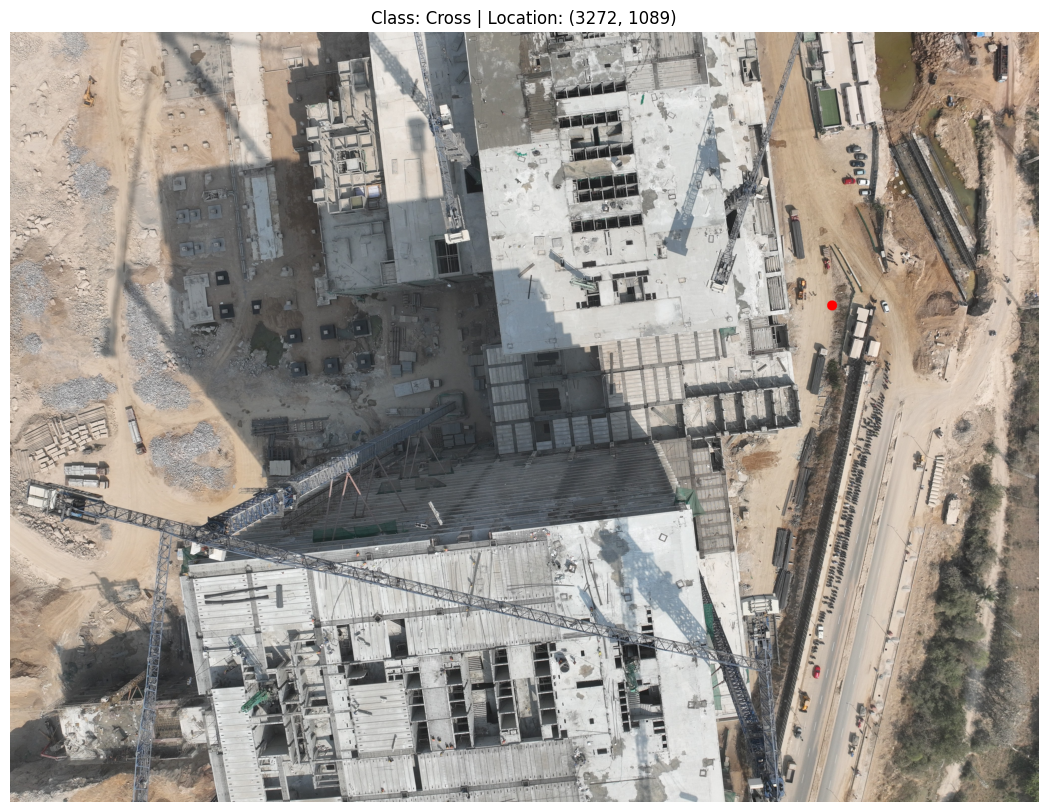

In [ ]:
#Performs visual Exploratory Data Analysis (EDA) by loading a sample image and plotting a red dot to verify coordinate accuracy.
import os
import json
import cv2
import matplotlib.pyplot as plt

# 1. setup paths
dataset_path = '/content/drive/MyDrive/GCP_Assignment_Datasets'
train_dir = os.path.join(dataset_path, 'train_dataset')
json_path = os.path.join(train_dir, 'gcp_marks.json') # <-- Fixed name!

# 2.load json
with open(json_path, 'r') as f:
    gcp_data = json.load(f)

print(f"Successfully loaded {len(gcp_data)} training records!")

# 3. visualize image
sample_path = list(gcp_data.keys())[0]
annotation = gcp_data[sample_path]

# path construction
img_path = os.path.join(train_dir, sample_path)

# read the image
img = cv2.imread(img_path)

if img is None:
    print(f"Error: Could not read image at {img_path}.")
else:

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # extract coordinates and labeling
    x = int(annotation['mark']['x'])
    y = int(annotation['mark']['y'])
    shape_label = annotation['verified_shape']

    # red circle constrction
    cv2.circle(img_rgb, (x, y), radius=20, color=(255, 0, 0), thickness=-1)

    # image display
    plt.figure(figsize=(15, 10))
    plt.imshow(img_rgb)
    plt.title(f"Class: {shape_label} | Location: ({x}, {y})")
    plt.axis('off')
    plt.show()

In [ ]:
#Implements a crucial Data Cleaning filter to drop hundreds of corrupt/missing labels and creates a clean DataLoader. (Note: Make sure to run this cell BEFORE Cell 5 when doing your final 15-epoch training!)
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import json
import os
import cv2

class GCPDataset(Dataset):
    def __init__(self, json_file, img_dir, transform=None):
        with open(json_file, 'r') as f:
            raw_data = json.load(f)

        self.data = {}
        self.skipped_count = 0


        # We loop through the raw data and only keep entries that have BOTH
        # a coordinate ('mark') and a shape label ('verified_shape').
        for img_path, ann in raw_data.items():
            if 'mark' in ann and 'verified_shape' in ann:

                if ann['verified_shape'] in ["Cross", "Square", "L-Shaped"]:
                    self.data[img_path] = ann
                else:
                    self.skipped_count += 1
            else:
                self.skipped_count += 1

        print(f"Data Cleaning Complete! Kept {len(self.data)} valid images. Skipped {self.skipped_count} messy/incomplete labels.")

        self.img_paths = list(self.data.keys())
        self.img_dir = img_dir
        self.transform = transform

        self.label_map = {"Cross": 0, "Square": 1, "L-Shaped": 2}

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_rel_path = self.img_paths[idx]
        img_path = os.path.join(self.img_dir, img_rel_path)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann = self.data[img_rel_path]
        x = float(ann['mark']['x'])
        y = float(ann['mark']['y'])
        shape_str = ann['verified_shape']
        shape_label = self.label_map[shape_str]

        if self.transform:
            transformed = self.transform(image=image, keypoints=[[x, y]])
            image = transformed['image']

            if len(transformed['keypoints']) > 0:
                x, y = transformed['keypoints'][0]
            else:
                x, y = 0.0, 0.0

        _, h, w = image.shape
        x_norm = np.clip(x / w, 0.0, 1.0)
        y_norm = np.clip(y / h, 0.0, 1.0)

        coords = torch.tensor([x_norm, y_norm], dtype=torch.float32)
        shape_label = torch.tensor(shape_label, dtype=torch.long)

        return image, coords, shape_label

# --- Re-instantiate the Dataset and DataLoader ---
train_transform = A.Compose([
    A.Resize(width=512, height=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

# Re-create dataset with the cleaning logic
train_dataset = GCPDataset(json_file=json_path, img_dir=train_dir, transform=train_transform)

# Re-create the DataLoader so it uses the clean dataset
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

Data Cleaning Complete! Kept 505 valid images. Skipped 495 messy/incomplete labels.


In [ ]:
#Constructs the Multi-Task ResNet-50 neural network with a bifurcated head (one predicting coordinates, one predicting shapes).
import torch.nn as nn
from torchvision import models

class GCPMultiTaskModel(nn.Module):
    def __init__(self):
        super(GCPMultiTaskModel, self).__init__()

        # 1. Load pre-trained ResNet50 backbone

        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)


        in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Identity()

        # 2.regression head working
        self.regression_head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Linear(256, 2),
            nn.Sigmoid() #forces op to 0/1
        )

        # 3. prediction of shape
        self.classification_head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        # image through backbone for feature mapping
        features = self.backbone(x)


        pred_coords = self.regression_head(features)
        pred_shape_logits = self.classification_head(features)

        return pred_coords, pred_shape_logits


# Initialize the model
model = GCPMultiTaskModel()

dummy_input = img_tensor.unsqueeze(0)

# pass through the model
pred_coords, pred_shape = model(dummy_input)

print(f"Predicted Coordinates Shape: {pred_coords.shape} | Output: {pred_coords.detach().numpy()}")
print(f"Predicted Shape Logits Shape: {pred_shape.shape} | Output: {pred_shape.detach().numpy()}")

Predicted Coordinates Shape: torch.Size([1, 2]) | Output: [[0.50479805 0.50574684]]
Predicted Shape Logits Shape: torch.Size([1, 3]) | Output: [[ 0.03999193  0.02818655 -0.0172395 ]]


In [ ]:
#Note: Initial EDA revealed that ~50% of the dataset lacked shape labels.
#This Dataset class includes a filter to sanitize the data and ensure training stability.
#Sets up the loss functions, moves the model to the GPU, and executes the PyTorch training loop to teach the model.
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm # For a progress bar

#  Move model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Training on device: {device}")

# Setup the DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

#  Define the two different Loss Functions and the Optimizer
criterion_regression = nn.MSELoss()
criterion_classification = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) # 1e-4 is a safe learning rate for ResNet

# training loop (15 epoch to load)
num_epochs = 15

for epoch in range(num_epochs):
    model.train()

    # start progress bar
    loop = tqdm(train_loader, total=len(train_loader), leave=True)

    for images, coords, shapes in loop:
        # dat -> gpu
        images = images.to(device)
        coords = coords.to(device)
        shapes = shapes.to(device)

        # forward pass for generation
        optimizer.zero_grad()
        pred_coords, pred_shapes = model(images)

        # induvidual losses
        loss_reg = criterion_regression(pred_coords, coords)
        loss_class = criterion_classification(pred_shapes, shapes)

        # combine losses
        total_loss = (loss_reg * 10.0) + loss_class

        # backward pass
        total_loss.backward()
        optimizer.step()

        # Update the progress bar
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=total_loss.item(), loss_reg=loss_reg.item(), loss_class=loss_class.item())

print("\nSuccess! The training loop is fully functional.")

Training on device: cuda


Epoch [12/15]:  31%|███▏      | 10/32 [00:19<00:38,  1.76s/it, loss=0.0508, loss_class=0.00177, loss_reg=0.0049]

In [38]:
#Runs the trained model on the unlabelled test images, scales the predicted coordinates back up to 4K resolution, and saves the final predictions.json and model weights.
import os
import glob
import json
import torch
import cv2
import numpy as np
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# save trained model weights
weights_path = 'best_model.pth'
torch.save(model.state_dict(), weights_path)
print(f"Model weights saved to {weights_path}")

# setup interference paths
dataset_path = '/content/drive/MyDrive/GCP_Assignment_Datasets'
test_dir = os.path.join(dataset_path, 'test_dataset')
output_json = 'predictions.json'

# setup test transform
test_transform = A.Compose([
    A.Resize(width=512, height=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# give predictions
def generate_predictions(model, test_dir, output_json):
    model.eval() # Set to evaluation mode
    predictions = {}
    idx_to_shape = {0: "Cross", 1: "Square", 2: "L-Shaped"}

    # find shapes to test recursively
    test_images = glob.glob(os.path.join(test_dir, '**', '*.JPG'), recursive=True)
    test_images += glob.glob(os.path.join(test_dir, '**', '*.jpg'), recursive=True)

    print(f"Found {len(test_images)} images in the test dataset. Starting inference...")

    with torch.no_grad(): # No gradients needed for inference
        for img_path in tqdm(test_images, desc="Predicting on Test Set"):
            # Get the relative path
            rel_path = os.path.relpath(img_path, test_dir)

            # read img in orignal dimension
            image = cv2.imread(img_path)
            if image is None:
                continue
            orig_h, orig_w = image.shape[:2]

            # preprocess ig
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            transformed = test_transform(image=image)
            input_tensor = transformed['image'].unsqueeze(0).to(device)

            # Forward Pass
            pred_coords, pred_shape_logits = model(input_tensor)

            # Process Shape
            shape_idx = torch.argmax(pred_shape_logits, dim=1).item()
            predicted_shape = idx_to_shape[shape_idx]

            # Process Coordinates
            x_norm, y_norm = pred_coords[0].cpu().numpy()
            x_original = float(x_norm * orig_w)
            y_original = float(y_norm * orig_h)

            # save in exact format
            predictions[rel_path] = {
                "mark": {
                    "x": round(x_original, 1),
                    "y": round(y_original, 1)
                },
                "verified_shape": predicted_shape
            }

    # save dict to json
    with open(output_json, 'w') as f:
        json.dump(predictions, f, indent=4)

    print(f"\nSUCCESS! Saved predictions to {output_json}")


generate_predictions(model, test_dir, output_json)

Model weights saved to best_model.pth
Found 300 images in the test dataset. Starting inference...


Predicting on Test Set: 100%|██████████| 300/300 [00:46<00:00,  6.51it/s]


SUCCESS! Saved predictions to predictions.json
